# Time Series Anomaly Detection

Detecting unusual patterns in time series is critical across many domains — fraud detection, IT operations monitoring, manufacturing quality control, and more. Unlike static anomaly detection, time series methods must handle temporal context, seasonality, and trend.

**Covered methods:**

| Method | Approach | Strengths |
|--------|----------|-----------|
| Z-score / IQR | Statistical thresholds | Simple, interpretable |
| STL Decomposition | Residual-based | Handles seasonality |
| ARIMA Residuals | Model-based | Trend-aware |
| Isolation Forest | ML-based | Multivariate, no assumptions |
| Matrix Profile (STUMPY) | Distance-based | Discord (rare subsequence) detection |
| LSTM Autoencoders | Deep learning | Complex temporal patterns |

**Contents:**
1. Generate Synthetic Anomalous Time Series
2. Statistical Methods (Z-score, IQR, MAD)
3. STL Decomposition Residual Method
4. ARIMA-based Anomaly Detection
5. Isolation Forest for Multivariate TS
6. Matrix Profile with STUMPY
7. Evaluation: Precision, Recall, F1 for Anomaly Detection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded')

Libraries loaded


## 1. Generate Synthetic Anomalous Time Series

We create a realistic time series with:
- Trend component
- Seasonal component (weekly + daily)
- Gaussian noise
- Injected anomalies: point anomalies, contextual anomalies, and collective anomalies

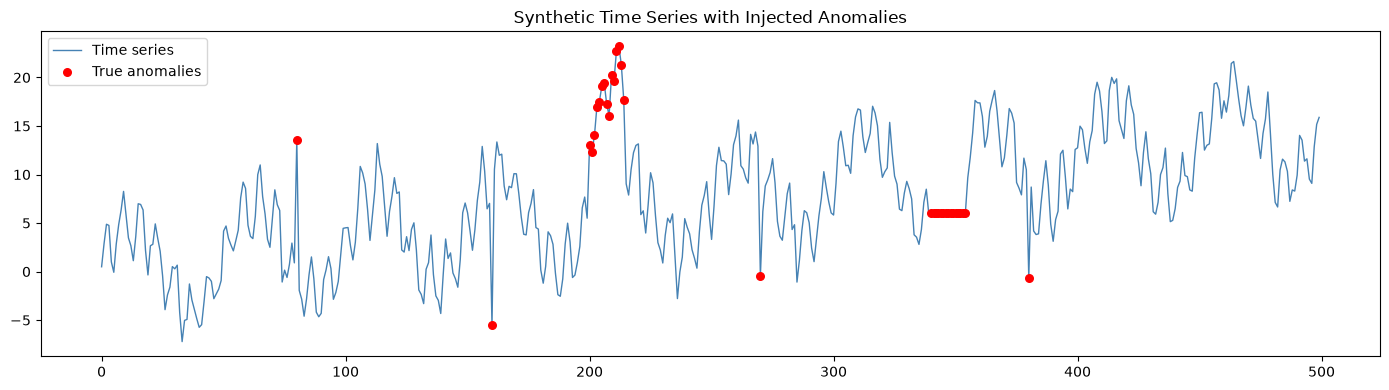

Total points: 500, Anomalies: 34 (6.8%)


In [2]:
def generate_ts_with_anomalies(n=500, seed=42):
    np.random.seed(seed)
    t = np.arange(n)
    # Components
    trend     = 0.03 * t
    seasonal  = 5 * np.sin(2 * np.pi * t / 50)  + 3 * np.sin(2 * np.pi * t / 7)
    noise     = np.random.normal(0, 1, n)
    ts        = trend + seasonal + noise
    
    # Inject anomalies
    labels    = np.zeros(n, dtype=int)
    anomaly_indices = []
    
    # Point anomalies (sudden spikes)
    for idx in [80, 160, 270, 380]:
        ts[idx] += np.random.choice([-1, 1]) * np.random.uniform(10, 15)
        labels[idx] = 1
        anomaly_indices.append(idx)
    
    # Contextual anomalies (level shift)
    ts[200:215] += 8
    labels[200:215] = 1
    anomaly_indices.extend(range(200, 215))
    
    # Collective anomaly (flat segment — sensor stuck)
    ts[340:355] = ts[339]  # freeze at constant
    labels[340:355] = 1
    anomaly_indices.extend(range(340, 355))
    
    return pd.Series(ts, name='value'), labels

ts, true_labels = generate_ts_with_anomalies()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts, lw=1, color='steelblue', label='Time series')
anom_idx = np.where(true_labels == 1)[0]
ax.scatter(anom_idx, ts.iloc[anom_idx], color='red', s=30, zorder=5, label='True anomalies')
ax.set_title('Synthetic Time Series with Injected Anomalies')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Total points: {len(ts)}, Anomalies: {true_labels.sum()} ({true_labels.mean():.1%})')

## 2. Statistical Methods: Z-score, IQR, MAD

**Z-score**: $(x - \mu) / \sigma$ — flag if $|z| > \text{threshold}$. Sensitive to outliers because mean/std themselves get skewed.

**IQR method**: Flag if $x < Q_1 - 1.5\cdot\text{IQR}$ or $x > Q_3 + 1.5\cdot\text{IQR}$. Robust — uses quartiles.

**Modified Z-score with MAD**: $0.6745 \cdot (x_i - \text{median}) / \text{MAD}$ — most robust, MAD = Median Absolute Deviation.

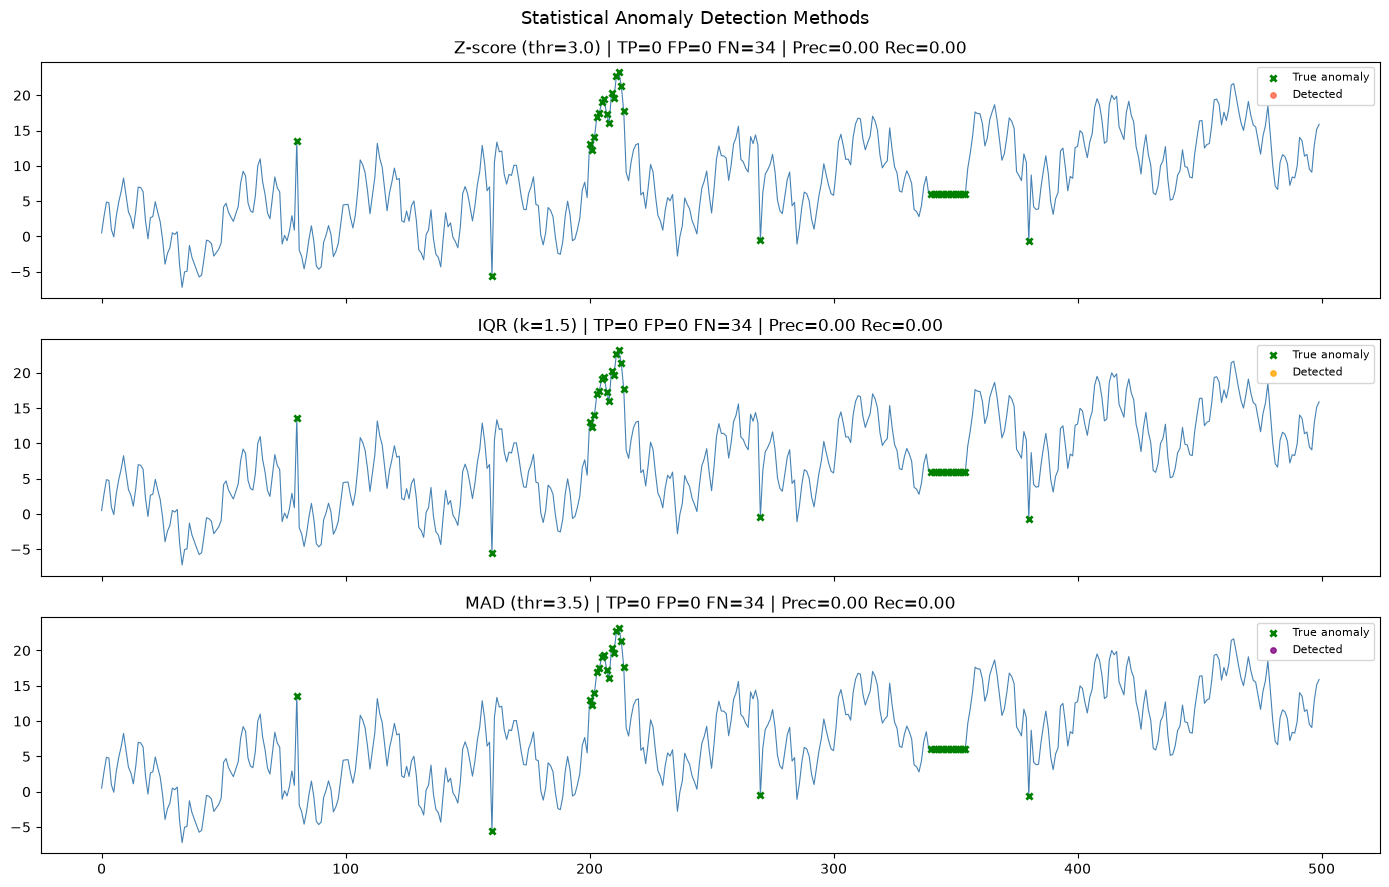

In [3]:
def zscore_anomalies(ts, threshold=3.0):
    z = np.abs((ts - ts.mean()) / ts.std())
    return (z > threshold).astype(int)

def iqr_anomalies(ts, k=1.5):
    Q1, Q3 = ts.quantile(0.25), ts.quantile(0.75)
    IQR = Q3 - Q1
    return ((ts < Q1 - k*IQR) | (ts > Q3 + k*IQR)).astype(int)

def mad_anomalies(ts, threshold=3.5):
    med = ts.median()
    MAD = (ts - med).abs().median()
    modified_z = 0.6745 * (ts - med) / (MAD + 1e-10)
    return (modified_z.abs() > threshold).astype(int)

pred_z   = zscore_anomalies(ts)
pred_iqr = iqr_anomalies(ts)
pred_mad = mad_anomalies(ts)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
methods = [('Z-score (thr=3.0)', pred_z, 'tomato'), ('IQR (k=1.5)', pred_iqr, 'orange'), ('MAD (thr=3.5)', pred_mad, 'purple')]

for ax, (name, pred, color) in zip(axes, methods):
    ax.plot(ts, lw=0.8, color='steelblue')
    ax.scatter(np.where(true_labels)[0], ts.iloc[np.where(true_labels)[0]], 
               color='green', s=20, zorder=4, label='True anomaly', marker='x', linewidths=2)
    ax.scatter(np.where(pred)[0], ts.iloc[np.where(pred)[0]],
               color=color, s=15, zorder=5, alpha=0.8, label='Detected')
    tp = int(np.sum((pred == 1) & (true_labels == 1)))
    fp = int(np.sum((pred == 1) & (true_labels == 0)))
    fn = int(np.sum((pred == 0) & (true_labels == 1)))
    prec = tp / (tp+fp+1e-9); rec = tp / (tp+fn+1e-9)
    ax.set_title(f'{name} | TP={tp} FP={fp} FN={fn} | Prec={prec:.2f} Rec={rec:.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Statistical Anomaly Detection Methods', fontsize=13)
plt.tight_layout(); plt.show()

## 3. STL Decomposition Residual Method

**STL (Seasonal and Trend decomposition using Loess)** splits the series into:
$$x_t = T_t + S_t + R_t$$
where $T_t$ = trend, $S_t$ = seasonal, $R_t$ = residual.

Anomalies are points where the **residual** is unusually large — they can't be explained by normal trend + seasonality.

STL Residuals | TP=23, FP=13, FN=11
Precision=0.639, Recall=0.676


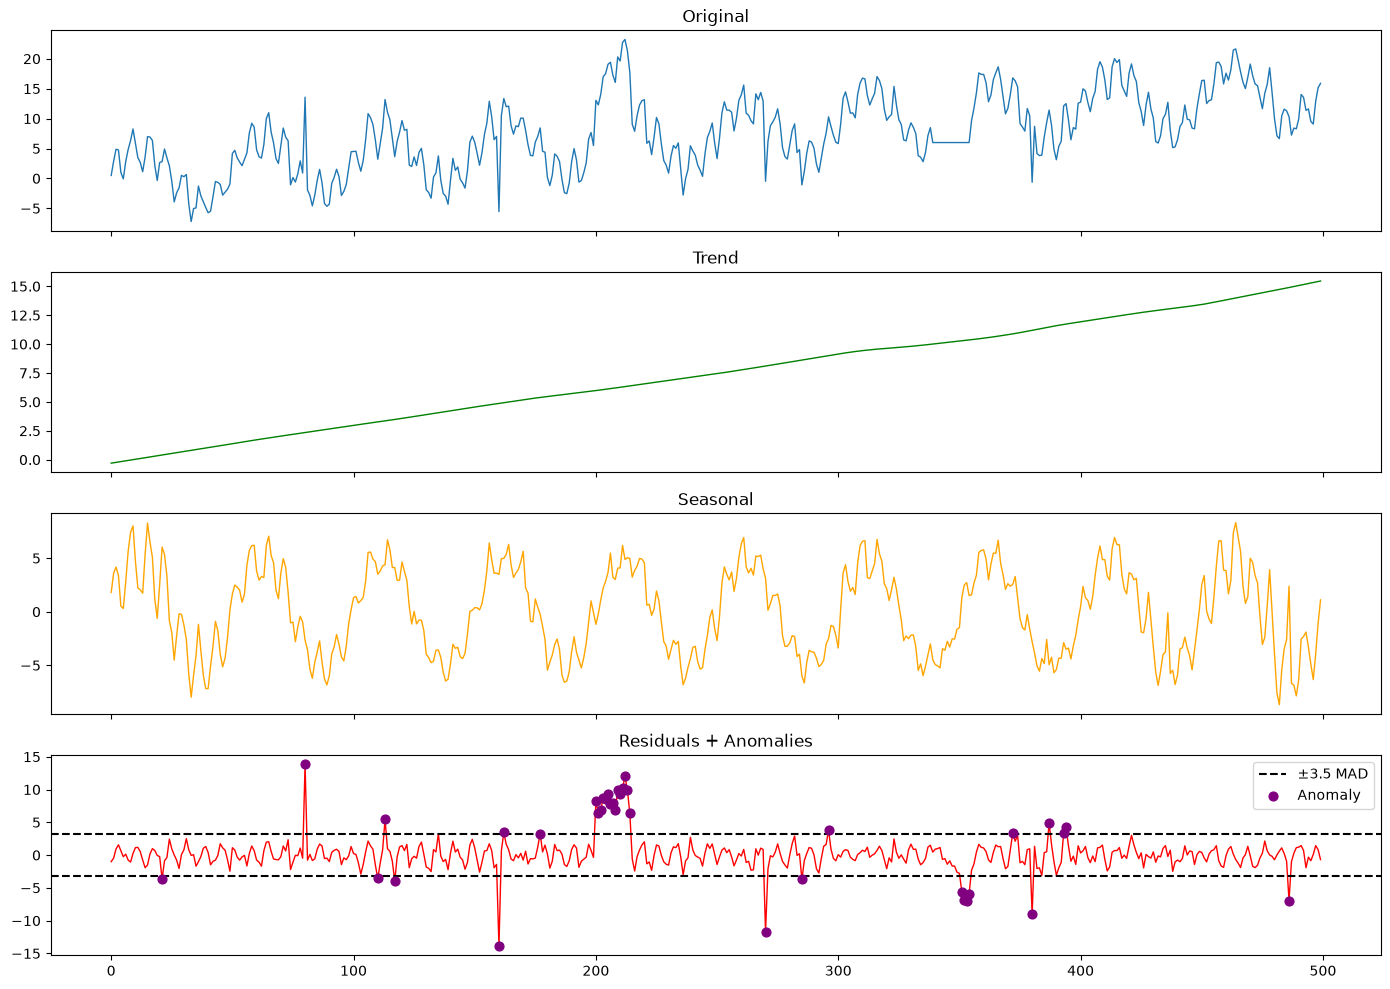

In [4]:
from statsmodels.tsa.seasonal import STL

stl = STL(ts, period=50, robust=True).fit()
residuals = stl.resid

# Flag residuals with |MAD-z| > 3.5
med_r = residuals.median()
MAD_r = (residuals - med_r).abs().median()
stl_scores = (residuals - med_r).abs() / (MAD_r + 1e-10)
pred_stl = (stl_scores > 3.5).astype(int)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(ts, lw=1); axes[0].set_title('Original')
axes[1].plot(stl.trend, lw=1, color='green'); axes[1].set_title('Trend')
axes[2].plot(stl.seasonal, lw=1, color='orange'); axes[2].set_title('Seasonal')
axes[3].plot(residuals, lw=1, color='red'); 
axes[3].axhline(3.5*MAD_r, color='k', linestyle='--', label='±3.5 MAD')
axes[3].axhline(-3.5*MAD_r, color='k', linestyle='--')
axes[3].scatter(np.where(pred_stl)[0], residuals.iloc[np.where(pred_stl)[0]], 
                color='purple', s=40, zorder=5, label='Anomaly')
axes[3].set_title('Residuals + Anomalies'); axes[3].legend()

tp = int(np.sum((pred_stl.values == 1) & (true_labels == 1)))
fp = int(np.sum((pred_stl.values == 1) & (true_labels == 0)))
fn = int(np.sum((pred_stl.values == 0) & (true_labels == 1)))
print(f'STL Residuals | TP={tp}, FP={fp}, FN={fn}')
print(f'Precision={tp/(tp+fp+1e-9):.3f}, Recall={tp/(tp+fn+1e-9):.3f}')
plt.tight_layout(); plt.show()

## 4. ARIMA Residual Anomaly Detection

Fit an ARIMA model on the "normal" portion of the data, then flag points where the model's **one-step-ahead forecast error** exceeds a threshold.

**Key idea:** An ARIMA model captures normal dynamics. Large residuals signal that the data violated those dynamics.

ARIMA | TP=5, FP=5, FN=29
Note: in-sample residuals are optimistic — for rigorous evaluation use rolling forecasts.


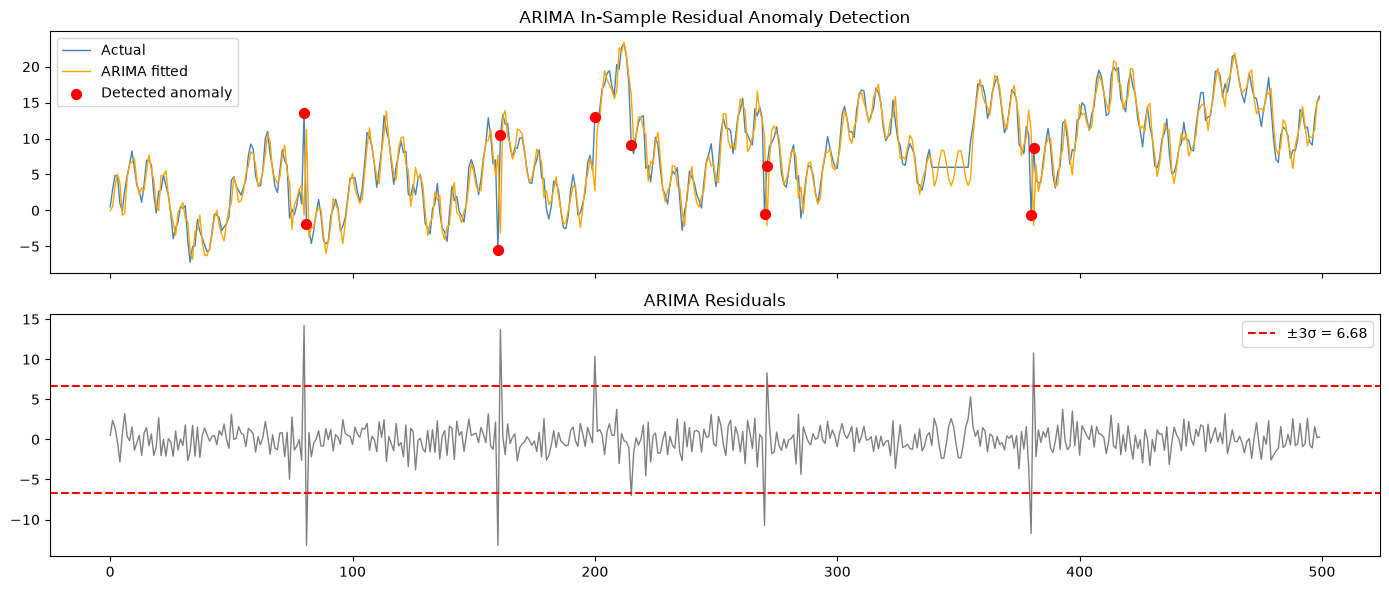

In [5]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA on the full series — use in-sample residuals to flag anomalies.
# This is much faster than rolling one-step-ahead refits and still illustrates the concept.
model_fit = ARIMA(ts, order=(2, 1, 2)).fit()
residuals_arima = model_fit.resid

# Flag residuals beyond 3 sigma as anomalies
resid_std = residuals_arima.std()
pred_arima = (np.abs(residuals_arima) > 3 * resid_std).astype(int)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(ts, lw=1, color='steelblue', label='Actual')
axes[0].plot(model_fit.fittedvalues, lw=1, color='orange', label='ARIMA fitted')
detected = np.where(pred_arima)[0]
axes[0].scatter(detected, ts.iloc[detected], color='red', s=50, zorder=5, label='Detected anomaly')
axes[0].set_title('ARIMA In-Sample Residual Anomaly Detection'); axes[0].legend()

axes[1].plot(residuals_arima, lw=1, color='gray')
thresh = 3 * resid_std
axes[1].axhline(thresh, color='red', linestyle='--', label=f'±3σ = {thresh:.2f}')
axes[1].axhline(-thresh, color='red', linestyle='--')
axes[1].set_title('ARIMA Residuals'); axes[1].legend()

true_sub = true_labels
tp = int(np.sum((pred_arima.values == 1) & (true_sub == 1)))
fp = int(np.sum((pred_arima.values == 1) & (true_sub == 0)))
fn = int(np.sum((pred_arima.values == 0) & (true_sub == 1)))
print(f'ARIMA | TP={tp}, FP={fp}, FN={fn}')
print(f'Note: in-sample residuals are optimistic — for rigorous evaluation use rolling forecasts.')
plt.tight_layout(); plt.show()

## 5. Isolation Forest for Multivariate Time Series

**Isolation Forest** detects anomalies by randomly partitioning feature space. Anomalies are isolated with *fewer splits* than normal points.

For time series, we engineer features from a sliding window:
- Value at time $t$
- Rolling mean over past $k$ steps
- Rolling std over past $k$ steps
- Differenced value $x_t - x_{t-1}$

Isolation Forest | TP=12 FP=28 FN=22 | Prec=0.300 Rec=0.353 F1=0.324


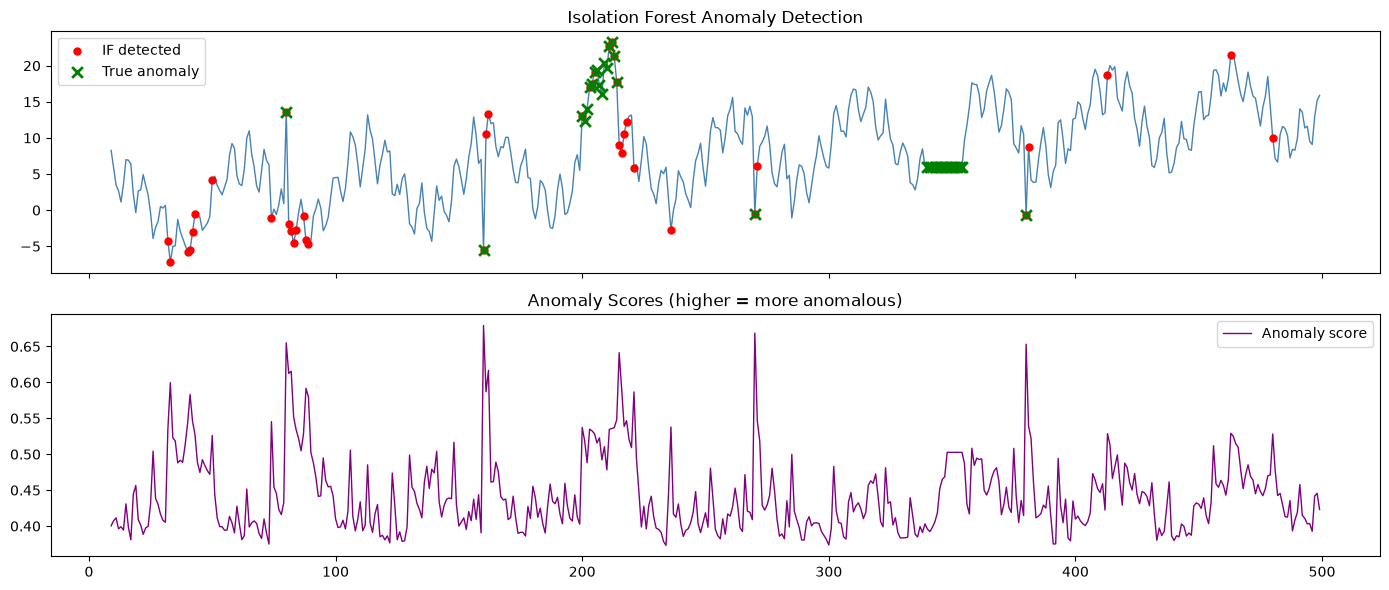

In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Feature engineering from sliding window
w = 10
df_feat = pd.DataFrame({'value': ts})
df_feat['rolling_mean'] = ts.rolling(w).mean()
df_feat['rolling_std']  = ts.rolling(w).std()
df_feat['diff1']        = ts.diff(1)
df_feat['diff2']        = ts.diff(2)
df_feat = df_feat.dropna()

X_feat = StandardScaler().fit_transform(df_feat)

iso = IsolationForest(contamination=0.08, random_state=42, n_estimators=200)
iso.fit(X_feat)
pred_iso_raw = iso.predict(X_feat)  # -1 = anomaly, 1 = normal
pred_iso = (pred_iso_raw == -1).astype(int)
scores_iso = -iso.score_samples(X_feat)  # higher = more anomalous

start_idx = len(ts) - len(df_feat)
true_sub = true_labels[start_idx:]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
x_range = np.arange(start_idx, len(ts))
axes[0].plot(x_range, ts.iloc[start_idx:].values, lw=1, color='steelblue')
anom_x = x_range[pred_iso == 1]
anom_y = ts.iloc[start_idx:].values[pred_iso == 1]
axes[0].scatter(anom_x, anom_y, color='red', s=25, zorder=5, label='IF detected')
true_x = x_range[true_sub == 1]
true_y = ts.iloc[start_idx:].values[true_sub == 1]
axes[0].scatter(true_x, true_y, color='green', s=60, marker='x', lw=2, zorder=6, label='True anomaly')
axes[0].set_title('Isolation Forest Anomaly Detection'); axes[0].legend()
axes[1].plot(x_range, scores_iso, lw=1, color='purple', label='Anomaly score')
axes[1].set_title('Anomaly Scores (higher = more anomalous)'); axes[1].legend()

tp = int(np.sum((pred_iso == 1) & (true_sub == 1)))
fp = int(np.sum((pred_iso == 1) & (true_sub == 0)))
fn = int(np.sum((pred_iso == 0) & (true_sub == 1)))
prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9); f1 = 2*prec*rec/(prec+rec+1e-9)
print(f'Isolation Forest | TP={tp} FP={fp} FN={fn} | Prec={prec:.3f} Rec={rec:.3f} F1={f1:.3f}')
plt.tight_layout(); plt.show()

## 6. Matrix Profile with STUMPY

**Matrix Profile** computes the z-normalized Euclidean distance between each subsequence and its nearest non-self-matching neighbour. A **discord** is a subsequence with an *unusually large nearest-neighbour distance* — it is the most unique subsequence in the series.

- MP[i] = distance from subsequence starting at i to its nearest neighbour
- High MP[i] → subsequence i is a **discord** (anomaly)
- Low MP[i] → subsequence i is a **motif** (frequently recurring pattern)

STUMPY implements this in O(n log n) with GPU acceleration.

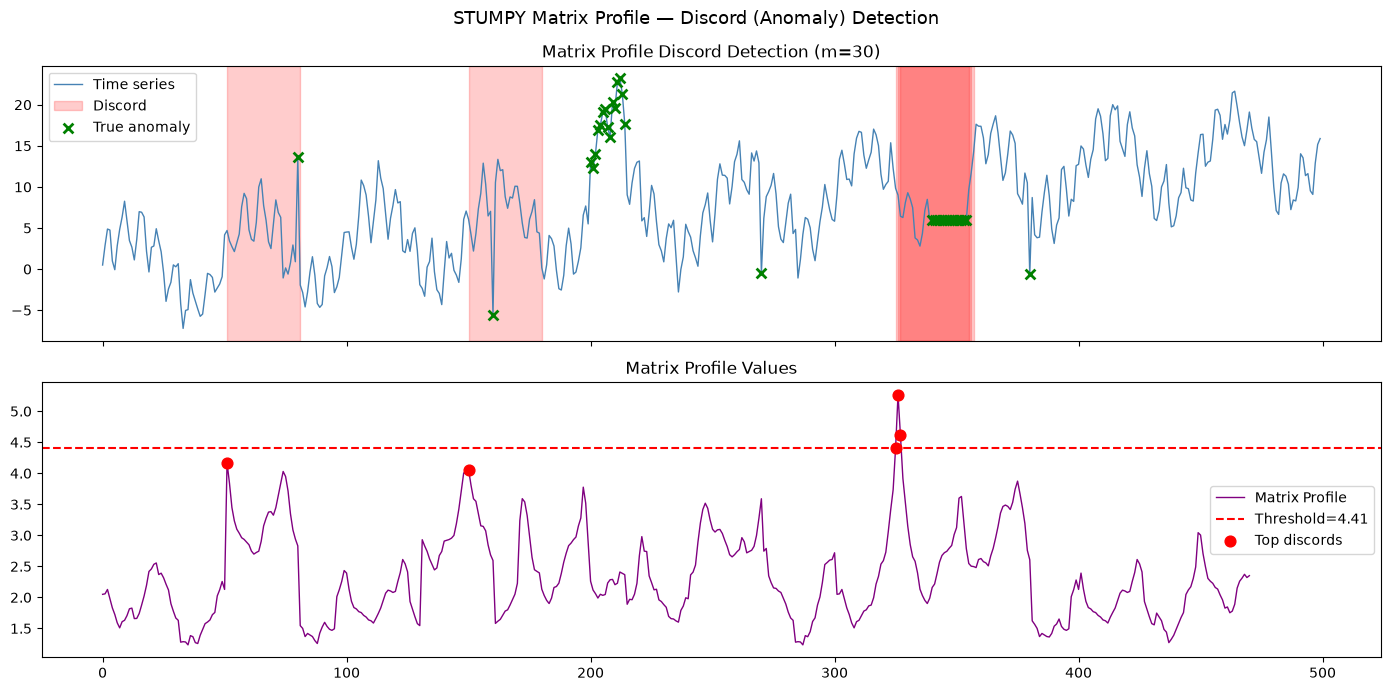

Top discord at index 326: MP distance = 5.2672
Threshold = 4.4097
Top-5 discord indices: [326 327 325  51 150]


In [7]:
import stumpy

ts_values = ts.values.astype(float)
m = 30  # subsequence window length

mp = stumpy.stump(ts_values, m=m)
mp_values = mp[:, 0].astype(float)  # first column is MP distances

# Discord = index of largest MP value
discord_idx  = np.argmax(mp_values)

# Identify top-5 discords
n_top = 5
discord_indices = np.argsort(mp_values)[-n_top:][::-1]

# Threshold: MP > mean + 3*std flags anomaly regions
mp_thresh = mp_values.mean() + 3 * mp_values.std()
pred_mp = np.zeros(len(ts), dtype=int)
for idx in discord_indices:
    pred_mp[idx:min(idx+m, len(ts))] = 1  # mark full subsequence

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(ts_values, lw=1, color='steelblue', label='Time series')
for i, idx in enumerate(discord_indices):
    axes[0].axvspan(idx, min(idx+m, len(ts)), alpha=0.2, color='red', label='Discord' if i==0 else '')
true_x = np.where(true_labels)[0]
axes[0].scatter(true_x, ts_values[true_x], color='green', marker='x', s=50, lw=2, zorder=6, label='True anomaly')
axes[0].set_title(f'Matrix Profile Discord Detection (m={m})')
axes[0].legend()

axes[1].plot(mp_values, lw=1, color='purple', label='Matrix Profile')
axes[1].axhline(mp_thresh, color='red', linestyle='--', label=f'Threshold={mp_thresh:.2f}')
axes[1].scatter(discord_indices, mp_values[discord_indices], color='red', s=60, zorder=5, label='Top discords')
axes[1].set_title('Matrix Profile Values'); axes[1].legend()

plt.suptitle('STUMPY Matrix Profile — Discord (Anomaly) Detection', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Top discord at index {discord_idx}: MP distance = {mp_values[discord_idx]:.4f}')
print(f'Threshold = {mp_thresh:.4f}')
print(f'Top-5 discord indices: {discord_indices}')

## 7. Method Comparison: Precision, Recall, F1

                  TP  FP  FN  Precision  Recall     F1
Method                                                
Z-score            0   0  34      0.000   0.000  0.000
IQR                0   0  34      0.000   0.000  0.000
MAD                0   0  34      0.000   0.000  0.000
STL Residuals     23  13  11      0.639   0.676  0.657
ARIMA Residuals    5   5  29      0.500   0.147  0.227
Isolation Forest  10  30  24      0.250   0.294  0.270
Matrix Profile    17  75  17      0.185   0.500  0.270


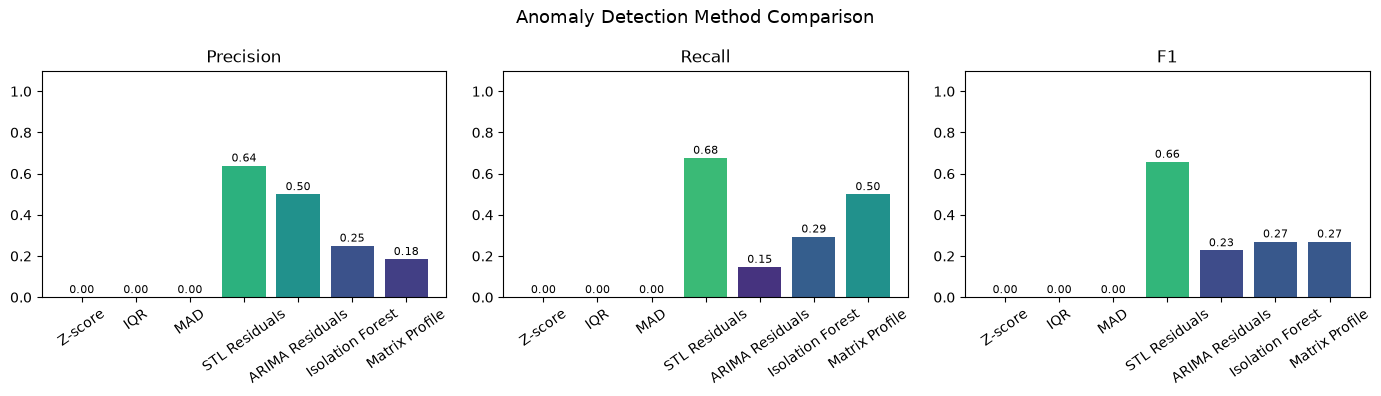

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate(name, pred, true, offset=0):
    p = pred[offset:]
    t = true[offset:]
    if len(p) > len(t): p = p[:len(t)]
    if len(t) > len(p): t = t[:len(p)]
    prec = precision_score(t, p, zero_division=0)
    rec  = recall_score(t, p, zero_division=0)
    f1   = f1_score(t, p, zero_division=0)
    tp   = int(np.sum((p==1)&(t==1))); fp = int(np.sum((p==1)&(t==0))); fn = int(np.sum((p==0)&(t==1)))
    return {'Method': name, 'TP': tp, 'FP': fp, 'FN': fn, 'Precision': prec, 'Recall': rec, 'F1': f1}

results = [
    evaluate('Z-score',         pred_z.values,        true_labels),
    evaluate('IQR',             pred_iqr.values,      true_labels),
    evaluate('MAD',             pred_mad.values,      true_labels),
    evaluate('STL Residuals',   pred_stl.values,      true_labels),
    evaluate('ARIMA Residuals', pred_arima.values,    true_labels),
    evaluate('Isolation Forest',pred_iso,             true_labels, offset=start_idx),
    evaluate('Matrix Profile',  pred_mp,              true_labels),
]
df_results = pd.DataFrame(results).set_index('Method')
print(df_results.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['Precision','Recall','F1']):
    vals = df_results[metric].values
    bars = ax.bar(df_results.index, vals, color=plt.cm.viridis(vals))
    ax.set_title(metric); ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=35)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.2f}', ha='center', fontsize=8)
plt.suptitle('Anomaly Detection Method Comparison', fontsize=13)
plt.tight_layout(); plt.show()

## Summary

| Method | Best for | Limitation |
|--------|----------|------------|
| Z-score / IQR | Quick exploration | Fails with seasonality |
| MAD | Robust point anomalies | Stationary data only |
| STL Residuals | Seasonal + trended TS | Assumes additive structure |
| ARIMA Residuals | Trended TS, online detection | Computationally expensive |
| Isolation Forest | Multivariate, high-dim | Window features need tuning |
| Matrix Profile | Discord patterns, motifs | Memory O(n) for large m |

**Practical tips:**
- Always start with STL decomposition + MAD residuals — it's surprisingly effective
- For multivariate TS (CPU metrics, sensor arrays) → Isolation Forest or LSTM autoencoder
- Matrix Profile excels at finding *contextual* anomalies (anomalous patterns, not just extreme values)
- Evaluation: use time-aware splits; never shuffle time series for train/test
- Point-adjust F1: when evaluating, consider a contiguous anomaly segment detected if **any** point in it is flagged

## Additional Learning Resources

- **[STUMPY Documentation](https://stumpy.readthedocs.io/)** — Matrix Profile library docs with tutorials
- **[Matrix Profile I (Yeh et al., 2016)](https://www.cs.ucr.edu/~eamonn/PID4481997_extend_Matrix%20Profile_I.pdf)** — Original STAMP paper
- **[Anomaly Detection Survey (Blazquez-Garcia et al., 2021)](https://arxiv.org/abs/2004.00433)** — Comprehensive taxonomy
- **[Merlion (Salesforce)](https://github.com/salesforce/Merlion)** — Production anomaly detection library
- **[PyOD](https://pyod.readthedocs.io/)** — 40+ anomaly detection algorithms
- **[Kats (Meta)](https://github.com/facebookresearch/Kats)** — Time series toolkit with anomaly detection
- **[Towards Data Science: Time Series Anomaly Detection](https://towardsdatascience.com/time-series-anomaly-detection-with-python-c3c30551d3f4)** — Practical overview